# Exploration — Dataset Mart Jürisoo + Calcul ELO
Pipeline : chargement → nettoyage → calcul ELO chronologique → équipes CdM 2026 → visualisation

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'

## 1. Chargement des données

In [25]:
# Chemin relatif depuis ml/notebooks/ → remonte deux niveaux vers ml/data/
df = pd.read_csv('../../ml/data/results.csv', parse_dates=['date'])

print(f'Matchs chargés : {len(df):,}')
print(f'Période        : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Équipes uniques: {pd.concat([df["home_team"], df["away_team"]]).nunique()}')
df.head()

Matchs chargés : 49,287
Période        : 1872-11-30 → 2026-06-27
Équipes uniques: 333


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [26]:
# Aperçu des types de tournois présents dans le dataset
print(df['tournament'].value_counts().head(20).to_string())

tournament
Friendly                                18252
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368


## 2. Calcul des ELO ratings

On parcourt tous les matchs **dans l'ordre chronologique** (obligatoire — l'ELO d'un match dépend de tous les matchs précédents).

Formule :
```
expected_home = 1 / (1 + 10^((elo_away - elo_home) / 400))
score         = 1 (victoire dom.) | 0.5 (nul) | 0 (défaite dom.)
Δ_home        = K × (score − expected_home)
Δ_away        = K × ((1−score) − (1−expected_home))
```

Facteur K par type de compétition :
- **40** → tournoi majeur (Coupe du Monde, Coupe continentale)
- **30** → match de qualification
- **20** → match amical ou autre

In [27]:
# --- Définition du facteur K ---
MAJOR_KEYWORDS = [
    'FIFA World Cup', 'UEFA Euro', 'Copa América',
    'Africa Cup of Nations', 'African Cup of Nations',
    'Asian Cup', 'AFC Asian Cup',
    'Gold Cup', 'CONCACAF Gold Cup',
    'Oceania Nations Cup',
]
QUAL_KEYWORDS = ['qualification', 'Qualification', 'qualifier', 'Qualifier']

def get_k(tournament: str) -> int:
    # Tester qualification en premier : 'FIFA World Cup qualification' → K=30, pas K=40
    if any(kw in tournament for kw in QUAL_KEYWORDS):
        return 30
    if any(kw in tournament for kw in MAJOR_KEYWORDS):
        return 40
    return 20

# Vérification rapide
for t in ['FIFA World Cup', 'FIFA World Cup qualification', 'UEFA Euro',
          'UEFA Euro qualification', 'Friendly', 'Copa América', 'UEFA Nations League']:
    print(f'K={get_k(t):2d}  →  {t}')

K=40  →  FIFA World Cup
K=30  →  FIFA World Cup qualification
K=40  →  UEFA Euro
K=30  →  UEFA Euro qualification
K=20  →  Friendly
K=40  →  Copa América
K=20  →  UEFA Nations League


In [28]:
# --- Tri chronologique (obligatoire avant tout calcul ELO) ---
df = df.sort_values('date').reset_index(drop=True)

elo_current  = {}      # état courant {team: elo}
ELO_INIT     = 1500.0
history_rows = []

for _, row in df.iterrows():
    home, away, date = row['home_team'], row['away_team'], row['date']

    elo_h = elo_current.get(home, ELO_INIT)
    elo_a = elo_current.get(away, ELO_INIT)

    expected_home = 1.0 / (1.0 + 10.0 ** ((elo_a - elo_h) / 400.0))

    if   row['home_score'] > row['away_score']: score = 1.0
    elif row['home_score'] == row['away_score']: score = 0.5
    else:                                        score = 0.0

    K = get_k(row['tournament'])
    new_elo_h = elo_h + K * (score - expected_home)
    new_elo_a = elo_a + K * ((1.0 - score) - (1.0 - expected_home))

    elo_current[home] = new_elo_h
    elo_current[away] = new_elo_a

    history_rows.append({'date': date, 'team': home, 'elo': new_elo_h})
    history_rows.append({'date': date, 'team': away, 'elo': new_elo_a})

elo_history = pd.DataFrame(history_rows)
print(f'Lignes dans elo_history : {len(elo_history):,}')
elo_history.head(6)

Lignes dans elo_history : 98,574


,date,team,elo
0,1872-11-30,Scotland,1500.000000
1,1872-11-30,England,1500.000000
2,1873-03-08,England,1510.000000
3,1873-03-08,Scotland,1490.000000
4,1874-03-07,Scotland,1500.575011
5,1874-03-07,England,1499.424989


In [29]:
# Classement ELO actuel — dernier ELO connu de chaque équipe
elo_latest = (
    elo_history.sort_values('date')
    .groupby('team', as_index=False).last()
    .sort_values('elo', ascending=False)
    .reset_index(drop=True)
)
elo_latest.index += 1
print('Top 20 ELO actuels :')
print(elo_latest[['team', 'elo']].head(20).to_string())

Top 20 ELO actuels :
           team          elo
1         Spain  1979.910403
2     Argentina  1970.209407
3        France  1940.498759
4       England  1888.657735
5       Morocco  1887.582468
6         Japan  1882.818178
7        Brazil  1875.405491
8   Netherlands  1867.727449
9      Portugal  1867.606552
10      Croatia  1864.688593
11      Germany  1863.178681
12     Colombia  1862.082746
13      Senegal  1851.893175
14        Italy  1849.494815
15       Turkey  1840.357443
16         Iran  1826.620052
17    Australia  1825.548241
18  Switzerland  1825.291887
19      Ecuador  1824.723120
20      Austria  1821.475062


## 3. Évolution ELO des 6 grandes nations (1990 → aujourd'hui)

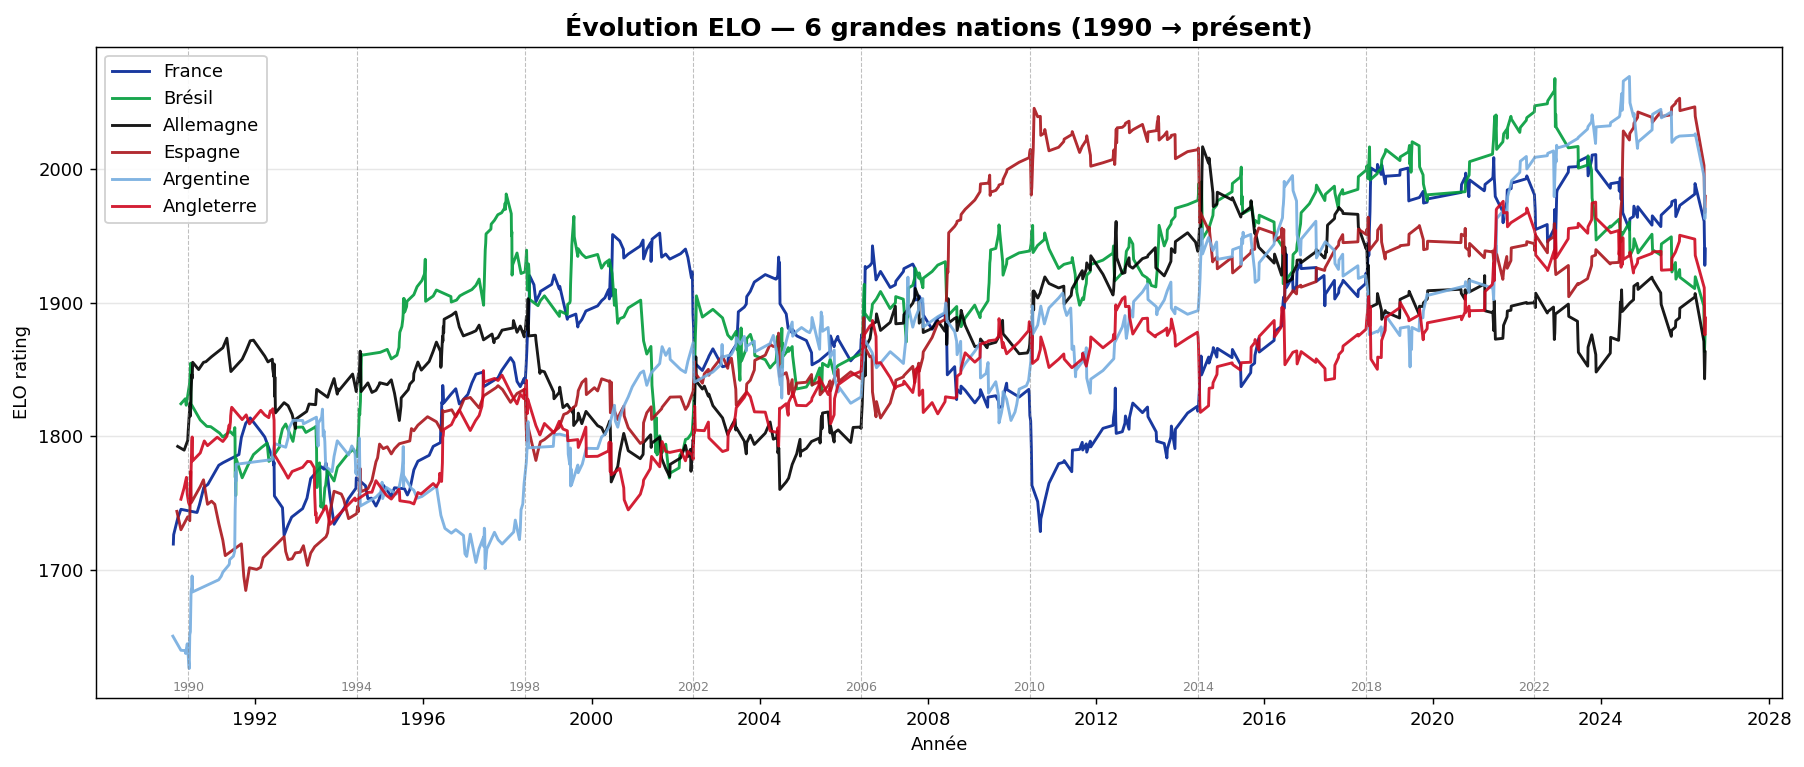

Graphique sauvegardé → ml/elo_evolution.png


In [30]:
NATIONS = ['France', 'Brazil', 'Germany', 'Spain', 'Argentina', 'England']
COLORS  = ['#002395', '#009C3B', '#000000', '#AA151B', '#74ACDF', '#CF081F']
LABELS  = ['France', 'Brésil', 'Allemagne', 'Espagne', 'Argentine', 'Angleterre']

mask = elo_history['team'].isin(NATIONS) & (elo_history['date'] >= '1990-01-01')
elo_6 = elo_history[mask].copy()

fig, ax = plt.subplots(figsize=(14, 6))
for nation, color, label in zip(NATIONS, COLORS, LABELS):
    data = elo_6[elo_6['team'] == nation].sort_values('date')
    ax.plot(data['date'], data['elo'], label=label, color=color, linewidth=1.6, alpha=0.9)

for yr in [1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]:
    ax.axvline(pd.Timestamp(f'{yr}-06-01'), color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
    ax.text(pd.Timestamp(f'{yr}-06-01'), ax.get_ylim()[0] + 5, str(yr),
            fontsize=7, color='gray', ha='center')

ax.set_title('Évolution ELO — 6 grandes nations (1990 → présent)', fontsize=14, fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('ELO rating')
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../elo_evolution.png', bbox_inches='tight')
plt.show()
print('Graphique sauvegardé → ml/elo_evolution.png')

## 4. Vérification des données — matchs Coupe du Monde

In [31]:
wc = df[df['tournament'] == 'FIFA World Cup'].copy()
print(f'Matchs World Cup : {len(wc)}')
print(f'Editions         : {sorted(wc["date"].dt.year.unique())}')
print()

wc['result'] = wc.apply(
    lambda r: 'Domicile/Neutre' if r['home_score'] > r['away_score']
              else ('Nul' if r['home_score'] == r['away_score'] else 'Extérieur'),
    axis=1
)
print('Distribution des résultats (World Cup, phase finale) :')
print(wc['result'].value_counts(normalize=True).map('{:.1%}'.format).to_string())

Matchs World Cup : 1036
Editions         : [1930, 1934, 1938, 1950, 1954, 1958, 1962, 1966, 1970, 1974, 1978, 1982, 1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022, 2026]

Distribution des résultats (World Cup, phase finale) :
result
Domicile/Neutre    42.4%
Extérieur          37.0%
Nul                20.7%


In [32]:
df['result'] = df.apply(
    lambda r: 'Home' if r['home_score'] > r['away_score']
              else ('Draw' if r['home_score'] == r['away_score'] else 'Away'),
    axis=1
)
print('Distribution globale (tous tournois) :')
print(df['result'].value_counts(normalize=True).map('{:.1%}'.format).to_string())
print()

df['decade'] = (df['date'].dt.year // 10) * 10
print('Matchs par décennie :')
print(df.groupby('decade').size().to_string())

Distribution globale (tous tournois) :
result
Home    48.9%
Away    28.4%
Draw    22.7%

Matchs par décennie :
decade
1870      13
1880      55
1890      59
1900     137
1910     330
1920     828
1930    1079
1940     833
1950    1651
1960    2971
1970    4133
1980    5025
1990    6944
2000    9525
2010    9756
2020    5948


## 5. Équipes qualifiées CdM 2026 — mapping des noms

Les noms officiels FIFA peuvent différer de ceux utilisés dans `results.csv`.
On construit un mapping explicite, on vérifie que toutes les équipes sont trouvées,
puis on filtre le classement ELO aux 48 équipes qualifiées.

In [33]:
WC2026_FIFA = {
    'Co-hôtes':  ['Canada', 'Mexico', 'USA'],
    'AFC':       ['Australia', 'Iraq', 'IR Iran', 'Japan', 'Jordan',
                  'Korea Republic', 'Qatar', 'Saudi Arabia', 'Uzbekistan'],
    'CAF':       ['Algeria', 'Cabo Verde', 'Congo DR', "Côte d'Ivoire",
                  'Egypt', 'Ghana', 'Morocco', 'Senegal', 'South Africa', 'Tunisia'],
    'CONCACAF':  ['Curaçao', 'Haiti', 'Panama'],
    'CONMEBOL':  ['Argentina', 'Brazil', 'Colombia', 'Ecuador', 'Paraguay', 'Uruguay'],
    'OFC':       ['New Zealand'],
    'UEFA':      ['Austria', 'Belgium', 'Bosnia and Herzegovina', 'Croatia',
                  'Czechia', 'England', 'France', 'Germany', 'Netherlands',
                  'Norway', 'Portugal', 'Scotland', 'Spain', 'Sweden',
                  'Switzerland', 'Türkiye'],
}

# Seuls les 8 noms qui divergent réellement entre FIFA et results.csv
# Bosnia and Herzegovina et Curaçao sont identiques dans les deux nomenclatures
FIFA_TO_DATASET = {
    'USA':            'United States',
    'IR Iran':        'Iran',
    'Korea Republic': 'South Korea',
    'Cabo Verde':     'Cape Verde',
    'Congo DR':       'DR Congo',
    "Côte d'Ivoire":  'Ivory Coast',
    'Czechia':        'Czech Republic',
    'Türkiye':        'Turkey',
}

wc_rows = []
for conf, teams in WC2026_FIFA.items():
    for t in teams:
        wc_rows.append({
            'confederation': conf,
            'fifa_name':     t,
            'dataset_name':  FIFA_TO_DATASET.get(t, t),
        })

wc_teams_df = pd.DataFrame(wc_rows)
print(f'Équipes listées : {len(wc_teams_df)} (attendu : 48)')

mapped = wc_teams_df[wc_teams_df['fifa_name'] != wc_teams_df['dataset_name']]
print(f'\nMappings FIFA → dataset appliqués ({len(mapped)}) :')
print(mapped[['fifa_name', 'dataset_name']].to_string(index=False))

Équipes listées : 48 (attendu : 48)

Mappings FIFA → dataset appliqués (8) :
     fifa_name   dataset_name
           USA  United States
       IR Iran           Iran
Korea Republic    South Korea
    Cabo Verde     Cape Verde
      Congo DR       DR Congo
 Côte d'Ivoire    Ivory Coast
       Czechia Czech Republic
       Türkiye         Turkey


In [34]:
# Vérification : tous les noms dataset sont-ils présents dans results.csv ?
all_dataset_teams = set(pd.concat([df['home_team'], df['away_team']]).unique())
dataset_names_48  = set(wc_teams_df['dataset_name'])

missing = dataset_names_48 - all_dataset_teams
if missing:
    print(f'ATTENTION — {len(missing)} équipe(s) introuvable(s) dans results.csv :')
    for m in sorted(missing):
        print(f'  ✗  "{m}"  — corriger FIFA_TO_DATASET')
else:
    print(f'OK — les {len(dataset_names_48)} noms sont tous présents dans results.csv.')

OK — les 48 noms sont tous présents dans results.csv.


In [35]:
# ELO final des 48 équipes qualifiées, triées par rating décroissant
elo_wc2026 = (
    elo_latest[elo_latest['team'].isin(dataset_names_48)]
    .merge(
        wc_teams_df[['dataset_name', 'confederation', 'fifa_name']],
        left_on='team', right_on='dataset_name',
        how='left'
    )
    .drop(columns=['dataset_name'])
    .sort_values('elo', ascending=False)
    .reset_index(drop=True)
)
elo_wc2026.index += 1
elo_wc2026['elo'] = elo_wc2026['elo'].round(1)

print('ELO des 48 équipes qualifiées CdM 2026 :')
print(elo_wc2026[['team', 'confederation', 'elo']].to_string())

ELO des 48 équipes qualifiées CdM 2026 :
                      team confederation     elo
1                    Spain          UEFA  1979.9
2                Argentina      CONMEBOL  1970.2
3                   France          UEFA  1940.5
4                  England          UEFA  1888.7
5                  Morocco           CAF  1887.6
6                    Japan           AFC  1882.8
7                   Brazil      CONMEBOL  1875.4
8              Netherlands          UEFA  1867.7
9                 Portugal          UEFA  1867.6
10                 Croatia          UEFA  1864.7
11                 Germany          UEFA  1863.2
12                Colombia      CONMEBOL  1862.1
13                 Senegal           CAF  1851.9
14                  Turkey          UEFA  1840.4
15                    Iran           AFC  1826.6
16               Australia           AFC  1825.5
17             Switzerland          UEFA  1825.3
18                 Ecuador      CONMEBOL  1824.7
19                 Austria  

## 6. Export — fichiers prêts pour le feature engineering

In [36]:
# elo_history  → forme récente et H2H dans features.py
# elo_latest   → ELO final de toutes les équipes
# elo_wc2026   → ELO des 48 qualifiées (point de départ prédictions)
# wc2026_teams → source de vérité pour les noms d'équipes dans tout le pipeline
elo_history.to_csv('../../ml/data/elo_history.csv', index=False)
elo_latest.to_csv('../../ml/data/elo_latest.csv', index=False)
elo_wc2026.to_csv('../../ml/data/elo_wc2026.csv', index=False)
wc_teams_df.to_csv('../../ml/data/wc2026_teams.csv', index=False)

print(f'elo_history.csv  — {len(elo_history):,} lignes')
print(f'elo_latest.csv   — {len(elo_latest):,} lignes')
print(f'elo_wc2026.csv   — {len(elo_wc2026):,} lignes')
print(f'wc2026_teams.csv — {len(wc_teams_df):,} lignes')

elo_history.csv  — 98,574 lignes
elo_latest.csv   — 333 lignes
elo_wc2026.csv   — 48 lignes
wc2026_teams.csv — 48 lignes
